This is the scratchpad to work out the code before rewriting it as a block script in volatility_renewable_share. I find it easier to debug and create in a notebook.

In [103]:
from pathlib import Path
import sys
sys.path.append("..") #notebook workaround for relative imports - not needed in the final script file
import pandas as pd
import statsmodels.formula.api as smf
from src.pipeline_utils import get_engine

In [106]:
engine = get_engine()
with engine.begin() as conn:
    df_generation = pd.read_sql("SELECT * FROM generation", conn)
df_generation["timestamp"] = pd.to_datetime(df_generation["timestamp"])

In [107]:
df_generation.head()

,zone,timestamp,production_type,value_mw
0,DE_LU,2026-09-14 22:00:00+00:00,Biomass,3847.93709
1,DE_LU,2026-09-14 22:15:00+00:00,Biomass,3832.25409
2,DE_LU,2026-09-14 22:30:00+00:00,Biomass,3821.68579
3,DE_LU,2026-09-14 22:45:00+00:00,Biomass,3812.94209
4,DE_LU,2026-09-14 23:00:00+00:00,Biomass,3798.16749


The where here is for future proofing. The one below. Build into the function for the script.

In [108]:
with engine.begin() as conn:
    df_price = pd.read_sql("SELECT * FROM prices WHERE zone IN ('DE_LU', 'SE_4')", conn)
df_price["timestamp"] = pd.to_datetime(df_price["timestamp"])

In [109]:
df_price.head()

,zone,timestamp,price_eur_mwh
0,DE_LU,2025-12-01 23:00:00+00:00,74.08
1,DE_LU,2025-12-01 23:15:00+00:00,69.92
2,DE_LU,2025-12-01 23:30:00+00:00,63.16
3,DE_LU,2025-12-01 23:45:00+00:00,55.95
4,DE_LU,2025-12-02 00:00:00+00:00,65.41


The clip here in the code below is to kill hydro water storage when negative which isnt strictly generation.

In [110]:
generation_wide_df = df_generation.pivot(index=['zone','timestamp'], columns='production_type', values='value_mw').clip(lower=0)

In [111]:
generation_wide_df.head()

production_type                      Biomass  Fossil Brown coal/Lignite  \
zone  timestamp                                                           
DE_LU 2025-12-01 23:00:00+00:00  3747.499144                 6912.68041   
      2025-12-01 23:15:00+00:00  3746.302984                 6923.59182   
      2025-12-01 23:30:00+00:00  3757.497088                 6915.54587   
      2025-12-01 23:45:00+00:00  3764.604516                 6854.23653   
      2025-12-02 00:00:00+00:00  3755.147836                 6596.57927   

production_type                  Fossil Coal-derived gas  Fossil Gas  \
zone  timestamp                                                        
DE_LU 2025-12-01 23:00:00+00:00                492.45667  6304.37520   
      2025-12-01 23:15:00+00:00                574.95667  6106.24293   
      2025-12-01 23:30:00+00:00                580.10334  6013.96636   
      2025-12-01 23:45:00+00:00                591.70667  5972.12206   
      2025-12-02 00:00:00+00:00                605.11334  6006.44944   

production_type                  Fossil Hard coal  Fossil Oil  Geothermal  \
zone  timestamp                                                             
DE_LU 2025-12-01 23:00:00+00:00        2659.07593   401.29800    34.06288   
      2025-12-01 23:15:00+00:00        2569.16804   399.94200    34.23812   
      2025-12-01 23:30:00+00:00        2499.61620   399.94200    34.14856   
      2025-12-01 23:45:00+00:00        2500.13420   399.94200    34.38876   
      2025-12-02 00:00:00+00:00        2497.30430   400.20867    34.43824   

production_type                  Hydro Pumped Storage  \
zone  timestamp                                         
DE_LU 2025-12-01 23:00:00+00:00                   0.0   
      2025-12-01 23:15:00+00:00                   0.0   
      2025-12-01 23:30:00+00:00                   0.0   
      2025-12-01 23:45:00+00:00                   0.0   
      2025-12-02 00:00:00+00:00                   0.0   

production_type                  Hydro Run-of-river and poundage  \
zone  timestamp                                                    
DE_LU 2025-12-01 23:00:00+00:00                       1447.43006   
      2025-12-01 23:15:00+00:00                       1449.20300   
      2025-12-01 23:30:00+00:00                       1446.75980   
      2025-12-01 23:45:00+00:00                       1439.94270   
      2025-12-02 00:00:00+00:00                       1442.12410   

production_type                  Hydro Water Reservoir      Other  \
zone  timestamp                                                     
DE_LU 2025-12-01 23:00:00+00:00                24.1717  222.39623   
      2025-12-01 23:15:00+00:00                31.3956  224.18423   
      2025-12-01 23:30:00+00:00                20.2129  224.41023   
      2025-12-01 23:45:00+00:00                23.1088  224.39323   
      2025-12-02 00:00:00+00:00                24.7121  218.17923   

production_type                  Other renewable     Solar    Waste  \
zone  timestamp                                                       
DE_LU 2025-12-01 23:00:00+00:00        89.339876  8.204348  735.495   
      2025-12-01 23:15:00+00:00        89.642020  8.257364  708.342   
      2025-12-01 23:30:00+00:00        89.952904  7.904608  708.654   
      2025-12-01 23:45:00+00:00        89.879208  7.934012  713.286   
      2025-12-02 00:00:00+00:00        89.782412  7.286076  706.126   

production_type                  Wind Offshore  Wind Onshore  
zone  timestamp                                               
DE_LU 2025-12-01 23:00:00+00:00       5419.125  29166.695404  
      2025-12-01 23:15:00+00:00       5644.271  28831.382340  
      2025-12-01 23:30:00+00:00       5711.357  28613.092408  
      2025-12-01 23:45:00+00:00       5761.216  28311.670976  
      2025-12-02 00:00:00+00:00       5819.805  28224.392636

The following works but should be prettier and can be a function. At the end there we do rolling average of generation share.

In [112]:
genx=generation_wide_df.reset_index().copy()
genx['renewables_generation']=genx[['Wind Onshore','Wind Offshore','Solar']].sum(axis=1)
production_cols = generation_wide_df.columns.tolist()
genx['total_generation_mw']=genx[production_cols].sum(axis=1)
genx['renewables_share']=genx['renewables_generation']/genx['total_generation_mw']
renewables_share_df=genx[["zone", "timestamp", "renewables_share"]].copy()
renewables_share_df["renewables_share_24h"] = (renewables_share_df.groupby("zone")["renewables_share"].rolling(96).mean().reset_index(level=0, drop=True))


In [113]:
renewables_share_df.head()

production_type,zone,timestamp,renewables_share,renewables_share_24h
0,DE_LU,2025-12-01 23:00:00+00:00,0.599921,NaN
1,DE_LU,2025-12-01 23:15:00+00:00,0.601382,NaN
2,DE_LU,2025-12-01 23:30:00+00:00,0.602077,NaN
3,DE_LU,2025-12-01 23:45:00+00:00,0.601194,NaN
4,DE_LU,2025-12-02 00:00:00+00:00,0.603454,NaN


Ok thats one of our final dataframes ready, lets do the other one. The volatility one.

In [114]:
df_price.head()

,zone,timestamp,price_eur_mwh
0,DE_LU,2025-12-01 23:00:00+00:00,74.08
1,DE_LU,2025-12-01 23:15:00+00:00,69.92
2,DE_LU,2025-12-01 23:30:00+00:00,63.16
3,DE_LU,2025-12-01 23:45:00+00:00,55.95
4,DE_LU,2025-12-02 00:00:00+00:00,65.41


In [115]:
df_generation["timestamp"] = pd.to_datetime(df_generation["timestamp"])
renewables_share_df["timestamp"] = pd.to_datetime(renewables_share_df["timestamp"])
df_price["timestamp"] = pd.to_datetime(df_price["timestamp"])
df_price = df_price.sort_values(["zone", "timestamp"]) #NEEDS TO BE SORTED!

In [116]:
df_price["volatility"] = (df_price.groupby("zone")["price_eur_mwh"].rolling(96).std().reset_index(level=0, drop=True))

In [117]:
df_price

,zone,timestamp,price_eur_mwh,volatility
0,DE_LU,2025-12-01 23:00:00+00:00,74.08,NaN
1,DE_LU,2025-12-01 23:15:00+00:00,69.92,NaN
2,DE_LU,2025-12-01 23:30:00+00:00,63.16,NaN
3,DE_LU,2025-12-01 23:45:00+00:00,55.95,NaN
4,DE_LU,2025-12-02 00:00:00+00:00,65.41,NaN
...,...,...,...,...
59125,SE_4,2026-10-05 21:00:00+00:00,48.74,46.882678
59126,SE_4,2026-10-05 21:15:00+00:00,40.94,47.047345
59127,SE_4,2026-10-05 21:30:00+00:00,25.99,47.431557
59128,SE_4,2026-10-05 21:45:00+00:00,24.84,47.830237


And time for the actual analysis file:

In [118]:
analysis_df = df_price.merge(renewables_share_df, on=["zone", "timestamp"], validate="one_to_one")

In [119]:
analysis_df

,zone,timestamp,price_eur_mwh,volatility,renewables_share,renewables_share_24h
0,DE_LU,2025-12-01 23:00:00+00:00,74.08,NaN,0.599921,NaN
1,DE_LU,2025-12-01 23:15:00+00:00,69.92,NaN,0.601382,NaN
2,DE_LU,2025-12-01 23:30:00+00:00,63.16,NaN,0.602077,NaN
3,DE_LU,2025-12-01 23:45:00+00:00,55.95,NaN,0.601194,NaN
4,DE_LU,2025-12-02 00:00:00+00:00,65.41,NaN,0.603454,NaN
...,...,...,...,...,...,...
59123,SE_4,2026-10-05 20:45:00+00:00,57.50,46.888739,0.936434,0.919819
59124,SE_4,2026-10-05 21:00:00+00:00,48.74,46.882678,0.936614,0.920298
59125,SE_4,2026-10-05 21:15:00+00:00,40.94,47.047345,0.935165,0.920747
59126,SE_4,2026-10-05 21:30:00+00:00,25.99,47.431557,0.934737,0.921123


sanity check:

In [120]:
analysis_df.groupby("zone").size()

zone
DE_LU    29564
SE_4     29564
dtype: int64

In [121]:
analysis_df.isna().sum()

zone                      0
timestamp                 0
price_eur_mwh             0
volatility              190
renewables_share          0
renewables_share_24h    190
dtype: int64

In [122]:
analysis_df.dropna(subset=["price_eur_mwh", "renewables_share", "renewables_share_24h", "volatility"], inplace=True)

And we can eyeball germany vs sweden now:

In [123]:
analysis_df.groupby("zone")[["renewables_share", "volatility"]].describe()

renewables_share                                                    \
                 count      mean       std       min       25%       50%   
zone                                                                       
DE_LU          29469.0  0.471229  0.215321  0.027862  0.298535  0.461347   
SE_4           29469.0  0.709549  0.195577  0.022814  0.604523  0.780120   

                          volatility                                  \
            75%       max      count       mean        std       min   
zone                                                                   
DE_LU  0.653541  0.867398    29469.0  47.283610  26.736753  6.558671   
SE_4   0.856618  0.963250    29469.0  37.120384  19.453479  1.361027   

                                                    
             25%        50%        75%         max  
zone                                                
DE_LU  26.519046  46.304934  62.371141  191.067875  
SE_4   22.402821  36.389740  48.754945  168.053600

OK some plots, code cribbed from claude this time, since seaborn is a bit annoying.

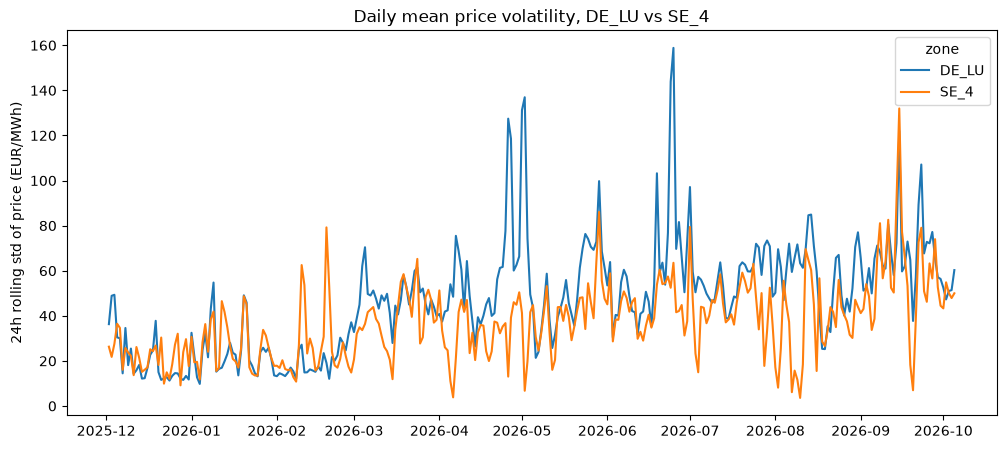

In [124]:
import matplotlib.pyplot as plt
import seaborn as sns

analysis_df["date"] = analysis_df["timestamp"].dt.date
daily_df = analysis_df.groupby(["zone", "date"])["volatility"].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=daily_df, x="date", y="volatility", hue="zone", ax=ax)
ax.set_title("Daily mean price volatility, DE_LU vs SE_4")
ax.set_xlabel("")
ax.set_ylabel("24h rolling std of price (EUR/MWh)")
fig.savefig("../outputs/figures/volatility_daily.png", dpi=150, bbox_inches="tight")
plt.show()

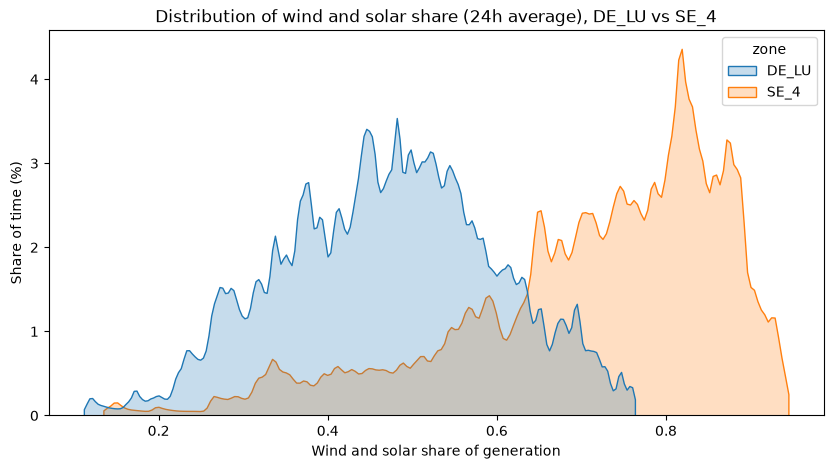

In [125]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(
    data=analysis_df,
    x="renewables_share_24h",
    hue="zone",
    common_norm=False,
    cut=0,
    bw_adjust=0.2,
    fill=True,
    ax=ax,
)
ax.set_title("Distribution of wind and solar share (24h average), DE_LU vs SE_4")
ax.set_xlabel("Wind and solar share of generation")
ax.set_ylabel("Share of time (%)")
fig.savefig("../outputs/figures/renewables_share_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

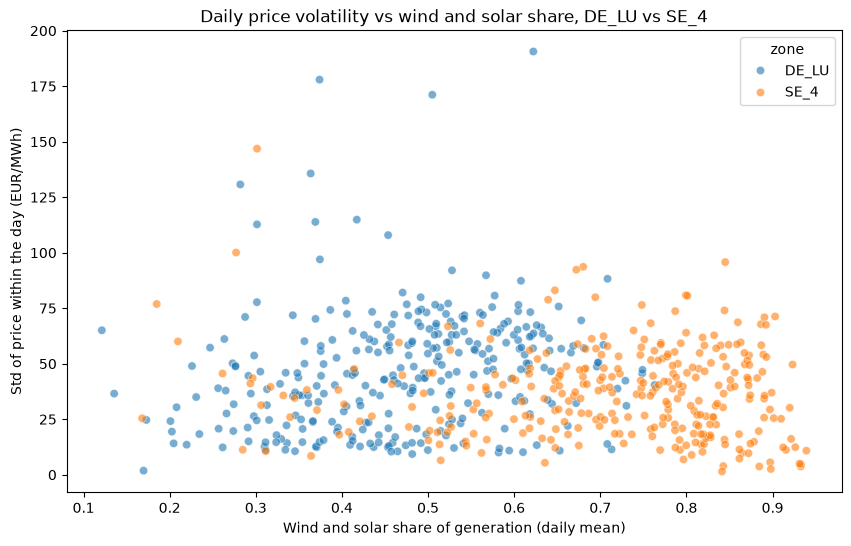

In [126]:
daily_points_df = (
    analysis_df.groupby(["zone", "date"])
    .agg(
        volatility=("price_eur_mwh", "std"),
        renewables_share=("renewables_share", "mean"),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=daily_points_df, x="renewables_share", y="volatility", hue="zone", alpha=0.6, ax=ax
)
ax.set_title("Daily price volatility vs wind and solar share, DE_LU vs SE_4")
ax.set_xlabel("Wind and solar share of generation (daily mean)")
ax.set_ylabel("Std of price within the day (EUR/MWh)")
fig.savefig("../outputs/figures/volatility_vs_renewables_share.png", dpi=150, bbox_inches="tight")
plt.show()

Ok that doesnt look structured at all.... like no correlation, and maye even Skedacisity or however its spelled. Lets try something else.

<Axes: xlabel='renewables_share_24h', ylabel='volatility'>

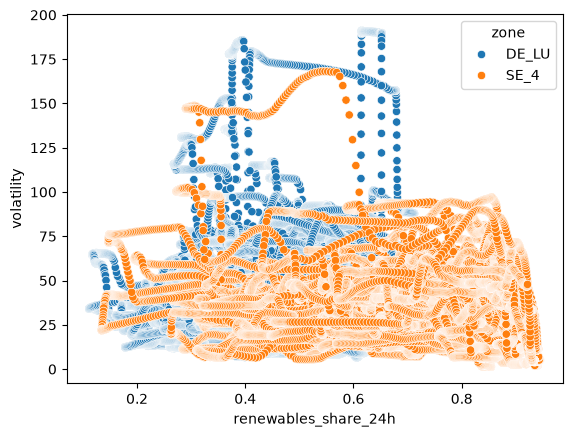

In [127]:
sns.scatterplot(data=analysis_df, x='renewables_share_24h', y='volatility', hue='zone')

Hmmm messy. And successive points share like 95% of datapoints feeding into the average from the rolling average, so of course we get trails. Never mind. Lets try something else.

In [ ]:
gen2x=generation_wide_df.reset_index().copy()
gen2x['renewables_generation']=gen2x[['Wind Onshore','Wind Offshore','Solar']].sum(axis=1)
production_cols = generation_wide_df.columns.tolist()
gen2x['total_generation_mw']=gen2x[production_cols].sum(axis=1)
gen2x['wind_share'] = gen2x[['Wind Onshore', 'Wind Offshore']].sum(axis=1) / gen2x['total_generation_mw']
gen2x['solar_share'] = gen2x['Solar'] / gen2x['total_generation_mw']
gen2x['renewables_share']=gen2x['renewables_generation']/gen2x['total_generation_mw']
renewables_share_split_df=gen2x[["zone", "timestamp", "renewables_share"]].copy()
renewables_share_split_df["renewables_share_24h"] = (renewables_share_split_df.groupby("zone")["renewables_share"].rolling(96).mean().reset_index(level=0, drop=True))

analysis_split_df = df_price.merge(renewables_share_split_df, on=["zone", "timestamp"], validate="one_to_one")